# Theory computation for second-order weak-lensing quantities

In [86]:
import camb
from camb import model
import numpy as np
import time

#Set up a new set of parameters for CAMB
pars = camb.CAMBparams()
A_s = 2.215e-9
n_s = 0.9619
h = 0.67
Omega_b = 0.049
Omega_cdm = 0.268580851704
T_cmb = 2.7255
N_ncdm = 2
N_ur = 1.01533

pars.set_cosmology(H0=100.0*h, ombh2=Omega_b*h*h, omch2=Omega_cdm*h*h, TCMB = T_cmb, omk=0, tau=0.06)
camb.set_params(num_nu_massless = 1.01533, num_nu_massive = 2, nu_mass_eigenstates = 2, nu_mass_degeneracies = [1, 1], nu_mass_numbers = [1, 1], nu_mass_fractions = [0.1481, 0.8519], share_delta_neff = True) 
pars.InitPower.set_params(As=A_s, ns=n_s, r=0)
pars.set_for_lmax(3500, lens_potential_accuracy=0);

# Integrals type 1

In [ ]:
"""
Here we report the relevant routines to estimate the rotation angular power spectrum and all the other terms
contributing to the shear B-modes. 
Portions of this code are adapted from CAMB (https://camb.info)
developed by Antony Lewis and Anthony Challinor.
See arXiv:1605.05662 for the methodology used here.
"""
import camb
from camb import model
import numpy as np

from scipy.interpolate import RectBivariateSpline, InterpolatedUnivariateSpline

"""
Compute integral type-1 for shear B-modes contributions, includes rotation. 
"""

def int_shearB_limber(string_int, results, PK, ls, nz, chi_source, setting, z_snap=0.25, chi_source2=None):
    chi_source = np.float64(chi_source)
    if chi_source2 is None:
        chi_source2 = chi_source
    else:
        chi_source2 = np.float64(chi_source2)
        if chi_source2 < chi_source:
            chi_source, chi_source2 = chi_source2, chi_source
    chis = np.linspace(0, chi_source, nz, dtype=np.float64)
    zs = results.redshift_at_comoving_radial_distance(chis)
    dchis = (chis[2:] - chis[:-2]) / 2
    chis = chis[1:-1]
    zs = zs[1:-1]
    if (string_int == 'int_rot'):
        win = (1 / chis - 1 / chi_source)**2 / chis ** 2
    elif (string_int == 'int_rot_cross_1'):
        win = (1 / chis - 1 / chi_source) / chis ** 3 
    elif (string_int == 'int_rot_cross_2'):
        win = (1 / chis - 1 / chi_source) / chis ** 2 
    elif (string_int == 'int_rot_cross_3'):
        win = (1 / chis - 1 / chi_source) / chis ** 2 * (3 - chi_source2 / chi_source + chi_source / chis) 
    elif (string_int == 'int_squares_c'):
        win = 1 / chis ** 2 
    elif (string_int == 'int_squares_d'):
        win = 1 / chis ** 2 * (3 - chi_source2 / chi_source + chi_source/chis) 
    elif (string_int == 'int_squares_e'):
        win = 1 / chis ** 2 * (3 - chi_source2 / chi_source + chi_source/chis)**2   
    elif (string_int == 'int_cross_norot_1'):
        win = 1 / chis ** 3  
    elif (string_int == 'int_cross_norot_2'):
        win = 1 / chis ** 3 * (3 - chi_source2 / chi_source + chi_source / chis) 
    elif (string_int == 'int_cross_norot_3'):
        win = 1 / chis ** 2
    elif (string_int == 'int_cross_norot_4'):
        win = 1 / chis ** 2 * (3 - chi_source2 / chi_source + chi_source / chis) 
    elif (string_int == 'int_eps_crossrot'):
        win = (1 / chis - 1 / chi_source)*(1/chis - 1 / chi_source2) / chis ** 2
    elif (string_int == 'int_eps_corr2'):
        win = (1 / chis - 1 / chi_source2) / chis ** 2
    elif (string_int == 'int_eps_corr3'):
        win =  (1/chis - 1 / chi_source2) * (3 - chi_source2 / chi_source + chi_source / chis)/ chis ** 2
    else:
        raise TypeError("Input not identified.")
    cl = np.zeros(ls.shape)
    w = np.ones(chis.shape)
    for i, l in enumerate(ls):
        k = (l + 0.5) / chis
        w[:] = 1
        w[k < 1e-4] = 0
        w[k >= PK.kmax] = 0
        if (setting == 'True'): 
            # compute the true contributions
            cl[i] = np.dot(dchis, w * PK.P(zs, k, grid=False) * win / k ** 4)
        elif (setting == 'comparison_sim'): 
            # estimate the power spectrum at fixed redshift (z_snap) following the approximation used in the simulation
            cl[i] = np.dot(dchis, w * PK.P(z_snap, k, grid=False) * win / k ** 4) 
    return cl

def get_integ_type1(string_int, params, setting, z_snap=0.25, kmax=100, lmax=20000, non_linear=True, z_source=None,
                             k_per_logint=None, acc=1, lsamp=None):

    results = camb.get_background(params)
    if z_source:
        chi_source = results.comoving_radial_distance(z_source)
    else:
        chi_source = results.tau0 - results.tau_maxvis
        z_source = results.redshift_at_comoving_radial_distance(chi_source)

    PK = camb.get_matter_power_interpolator(params, nonlinear=non_linear,
                                            hubble_units=False, k_hunit=False, kmax=kmax, k_per_logint=k_per_logint,
                                            var1=model.Transfer_Weyl, var2=model.Transfer_Weyl, zmax=z_source)
    return get_integ_from_PK_test(string_int, params, PK, chi_source, setting, z_snap, lmax, acc, lsamp)

def get_integ_from_PK_test(string_int, params, PK, chi_source, setting, z_snap=0.25, lmax=20000, acc=1, lsamp=None):
    results = camb.get_background(params)
    nz = int(100 * acc)
    if lmax < 3000:
        raise ValueError('field rotation assumed lmax > 3000')
    ls = np.hstack((np.arange(2, 1000, 1), np.arange(1001, 2600, int(10. / acc)),
                    np.arange(2650, lmax, int(50. / acc)), np.arange(lmax, lmax + 1))).astype(np.float64)

    # get grid of C_L(chi_s,k) for different redshifts
    chimaxs = np.linspace(0, chi_source, nz)
    cls = np.zeros((nz, ls.size))
    for i, chimax in enumerate(chimaxs[1:]):
        cl = int_shearB_limber(string_int, results, PK, ls, nz, chimax, setting, z_snap, chi_source2=chi_source)
        cls[i + 1, :] = cl
    cls[0, :] = 0
    cl_chi = RectBivariateSpline(chimaxs, ls, cls)

    # Get M(L,L') matrix
    chis = np.linspace(0, chi_source, nz, dtype=np.float64)
    zs = results.redshift_at_comoving_radial_distance(chis)
    dchis = (chis[2:] - chis[:-2]) / 2
    chis = chis[1:-1]
    zs = zs[1:-1]
    if (string_int == 'int_rot'):
        win = (1 / chis - 1 / chi_source) ** 2 / chis ** 2
    elif (string_int == 'int_rot_cross_1'):
        win = (1 / chis - 1 / chi_source) / chis ** 2
    elif (string_int == 'int_rot_cross_2'):
        win = (1 / chis - 1 / chi_source) / chis ** 3
    elif (string_int == 'int_rot_cross_3'):
        win =  (1 / chis - 1 / chi_source) / chis ** 3
    elif (string_int == 'int_squares_c'):
        win = 1 / chis ** 4 
    elif (string_int == 'int_squares_d'):
        win = 1 / chis ** 4  
    elif (string_int == 'int_squares_e'):
        win = 1 / chis ** 4  
    elif (string_int == 'int_cross_norot_1'):
        win = 1 / chis ** 3 
    elif (string_int == 'int_cross_norot_2'):
        win = 1 / chis ** 3 
    elif (string_int == 'int_cross_norot_3'):
        win = 1 / chis ** 4 
    elif (string_int == 'int_cross_norot_4'):
        win = 1 / chis ** 4 
    elif (string_int == 'int_eps_crossrot'):
        win = (1 / chis - 1 / chi_source) ** 2 / chis ** 2
    elif (string_int == 'int_eps_corr2'):
        win = (1 / chis - 1 / chi_source) / chis ** 3
    elif (string_int == 'int_eps_corr3'):
        win = (1 / chis - 1 / chi_source) / chis ** 3
    else:
        raise TypeError('Input not identified.') 
    w = np.ones(chis.shape)
    cchi = cl_chi(chis, ls, grid=True)
    M = np.zeros((ls.size, ls.size))
    for i, ell in enumerate(ls):
        k = (ell + 0.5) / chis
        w[:] = 1
        w[k < 1e-4] = 0
        w[k >= PK.kmax] = 0
        if (setting == 'True'):
            # compute the true contributions
            cl = np.dot(dchis * w * PK.P(zs, k, grid=False) * win / k ** 4, cchi)
        elif (setting == 'comparison_sim'):
            # estimate the power spectrum at fixed redshift (z_snap) following the approximation used in the simulation
            cl = np.dot(dchis * w * PK.P(z_snap, k, grid=False) * win / k ** 4, cchi)
        M[i, :] = cl 
    Mf = RectBivariateSpline(ls, ls, M)

    # L sampling for output
    if lsamp is None:
        lsamp = np.hstack((np.arange(2, 20, 2), np.arange(25, 200, 10 // acc), np.arange(220, 1200, 30 // acc),
                           np.arange(1300, min(lmax // 2, 2600), 150 // acc),
                           np.arange(3000, lmax // 2 + 1, 1000 // acc)))

    # Get diagonal matrix M and its spline
    diagm = np.diag(M)
    diagmsp = InterpolatedUnivariateSpline(ls, diagm)

    clcurl = np.zeros(lsamp.shape)
    lsall = np.arange(2, lmax + 1, dtype=np.float64)

    for i, ll in enumerate(lsamp):

        ell = np.float64(ll)
        lmin = lsall[0]
        lpmax = lmax
        
        if ll < 1500:
            lcalc = lsall[0:lpmax - 2]
        else:
            # sampling in L', with denser around L~L'
            lcalc = np.hstack((lsall[0:20:4],
                               lsall[29:ll - 200:35],
                               lsall[ll - 190:ll + 210:6],
                               lsall[ll + 220:lpmax + 60:60]))

        tmps = np.zeros(lcalc.shape)
        for ix, lp in enumerate(lcalc):
            llp = int(lp)
            lp = np.float64(lp)
            if abs(ll - llp) > 200 and lp > 200:
                nphi = 2 * int(min(lp / 10 * acc, 200)) + 1
            elif ll > 2000:
                nphi = 2 * int(lp / 10 * acc) + 1
            else:
                nphi = 2 * int(lp) + 1
            dphi = 2 * np.pi / nphi
            phi = np.linspace(dphi, (nphi - 1) / 2 * dphi, (nphi - 1) // 2)  # even and don't need zero
            w = 2 * np.ones(phi.size)
            cosphi = np.cos(phi)
            sinphi = np.sin(phi)
            lrat = lp / ell
            lfact = np.sqrt(1 + lrat ** 2 - 2 * cosphi * lrat)
            lnorm = ell * lfact
            lfact[lfact <= 0] = 1
            w[lnorm < lmin] = 0
            w[lnorm > lmax] = 0

            lnorm = np.maximum(lmin, np.minimum(lmax, lnorm))
            if (string_int == 'int_rot'):
                f_phiL = (ll*lp*sinphi)**2 *(lp*ll*cosphi - lp**2)**2
            elif (string_int == 'int_rot_cross_1'):
                f_phiL = ll*lp**3*cosphi*sinphi**2 * (ll*lp*cosphi - lp**2) #mod
            elif (string_int == 'int_rot_cross_2'):
                f_phiL = ll**2*lp**2*sinphi**2*(ll*lp*cosphi-lp**2) #mod
            elif (string_int == 'int_rot_cross_3'):
                f_phiL = ll*lp**3*cosphi*sinphi**2*(ll*lp*cosphi-lp**2) # mod
            elif (string_int == 'int_squares_c'):
                f_phiL = ll*2 * lp**2*sinphi**2 # mod
            elif (string_int == 'int_squares_d'):
                f_phiL = ll * lp**3 * cosphi * sinphi**2 #mod
            elif (string_int == 'int_squares_e'):
                f_phiL = lp** 4 * cosphi**2 * sinphi**2 #mod
            elif (string_int == 'int_cross_norot_1'):
                f_phiL = ll*lp**3*cosphi*sinphi**2 #mod
            elif (string_int == 'int_cross_norot_2'):
                f_phiL = lp**4*sinphi**2*cosphi**2 #mod
            elif (string_int == 'int_cross_norot_3'):
                f_phiL = ll**2*lp**2*sinphi**2 #mod
            elif (string_int == 'int_cross_norot_4'):
                f_phiL = lp**3*cosphi*sinphi*(lp*cosphi-ll) #mod
            elif (string_int == 'int_eps_crossrot'):
                f_phiL = ll*lp**2*sinphi**2*(ll*lp*cosphi-lp**2)*(lp*cosphi*(ll**2 + lp**2 -2.0*ll*lp*cosphi) + lp**2*(lp*cosphi-ll))
            elif (string_int == 'int_eps_corr2'):
                f_phiL = ll*lp**2*sinphi**2*(lp*cosphi*(ll**2 + lp**2 -2.0*ll*lp*cosphi) + lp**2*(lp*cosphi-ll))
            elif (string_int == 'int_eps_corr3'):
                f_phiL = lp**3*cosphi*sinphi**2*((lp*cosphi - ll)*(lp**2 + (ll**2 + lp**2 -2.0*ll*lp*cosphi)) + 2.0*lp*cosphi*(ll**2 + lp**2 -2.0*ll*lp*cosphi)) 
            else:
                raise TypeError('Input not identified.') 
            
            tmps[ix] += lp*np.dot(w,  (f_phiL * Mf(lnorm, lp, grid=False)) * dphi) #invert lp and lnorm to match the order in M matrix

        sp = InterpolatedUnivariateSpline(lcalc, tmps)
        if (string_int == 'int_rot'):
            K = 4.0
        elif (string_int == 'int_rot_cross_1'):
            K = -32.0/chi_source #mod
        elif (string_int == 'int_rot_cross_2'):
            K = -16.0/chi_source #mod
        elif (string_int == 'int_rot_cross_3'):
            K = 16.0/chi_source #mod
        elif (string_int == 'int_squares_c'):
            K = 64.0/(chi_source)**2 #mod
        elif (string_int == 'int_squares_d'):
            K = -64.0/(chi_source)**2
        elif (string_int == 'int_squares_e'):
            K = 16.0/(chi_source)**2
        elif (string_int == 'int_cross_norot_1'):
            K = 128.0/chi_source**2 #mod
        elif (string_int == 'int_cross_norot_2'):
            K = -64.0/chi_source**2 #mod
        elif (string_int == 'int_cross_norot_3'):
            K = -64.0/chi_source**2 #mod
        elif (string_int == 'int_cross_norot_4'):
            K = -64.0/chi_source**2 #mod
        elif (string_int == 'int_eps_crossrot'):
            K = 4.0
        elif (string_int == 'int_eps_corr2'):
            K = -16.0/chi_source
        elif (string_int == 'int_eps_corr3'):
            K = 8.0/chi_source
        else:
            raise TypeError('Input not identified.') 
        clcurl[i] = sp.integral(2, lpmax - 1) * K / (2 * np.pi) ** 2

    return lsamp, clcurl

In [108]:
z_source = 1.0
print('Compute integrals...')
setting = 'comparison_sim'
print('z_source: ', z_source)  
print('setting: ', setting)   
int_type = 'int_rot'
l, cl_shear_rot = get_integ_type1(int_type, pars, setting, z_snap = 0.25, kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)

print('int_rot done.')

int_type = 'int_rot_cross_1'
l, cl_shear_rot_cross_1 = get_integ_type1(int_type, pars, setting, z_snap = 0.25, kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)

print('int_rot_cross_1 done.')

int_type = 'int_rot_cross_2'
l, cl_shear_rot_cross_2 = get_integ_type1(int_type, pars, setting, z_snap = 0.25, kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)

print('int_rot_cross_2 done.')

int_type = 'int_rot_cross_3'
l, cl_shear_rot_cross_3 = get_integ_type1(int_type, pars, setting, z_snap = 0.25, kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)

print('int_rot_cross_3 done.')

int_type = 'int_cross_norot_1'
l, cl_shear_cross_norot_1 = get_integ_type1(int_type, pars, setting, z_snap = 0.25, kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)

print('int_cross_norot_1 done.')

int_type = 'int_cross_norot_2'
l, cl_shear_cross_norot_2 = get_integ_type1(int_type, pars, setting, z_snap = 0.25, kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)

print('int_cross_norot_2 done.')

int_type = 'int_cross_norot_3'
l, cl_shear_cross_norot_3 = get_integ_type1(int_type, pars, setting, z_snap = 0.25, kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)

print('int_cross_norot_3 done.')

int_type = 'int_cross_norot_4'
l, cl_shear_cross_norot_4 = get_integ_type1(int_type, pars, setting, z_snap = 0.25, kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)

print('int_cross_norot_4 done.')

int_type = 'int_squares_c'
l, cl_shear_squares_c = get_integ_type1(int_type, pars, setting, z_snap = 0.25, kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)

print('int_squares_c done.')

int_type = 'int_squares_d'
l, cl_shear_squares_d = get_integ_type1(int_type, pars, setting, z_snap = 0.25, kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)

print('int_squares_d done.')

int_type = 'int_squares_e'
l, cl_shear_squares_e = get_integ_type1(int_type, pars, setting, z_snap = 0.25,  kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)

print('int_squares_e done.')

print('Done.')

Compute integrals...
z_source:  1.0
setting:  comparison_sim
int_rot done.
int_rot_cross_1 done.
int_rot_cross_2 done.
int_rot_cross_3 done.
int_cross_norot_1 done.
int_cross_norot_2 done.
int_cross_norot_3 done.
int_cross_norot_4 done.
int_squares_c done.
int_squares_d done.
int_squares_e done.
Done.


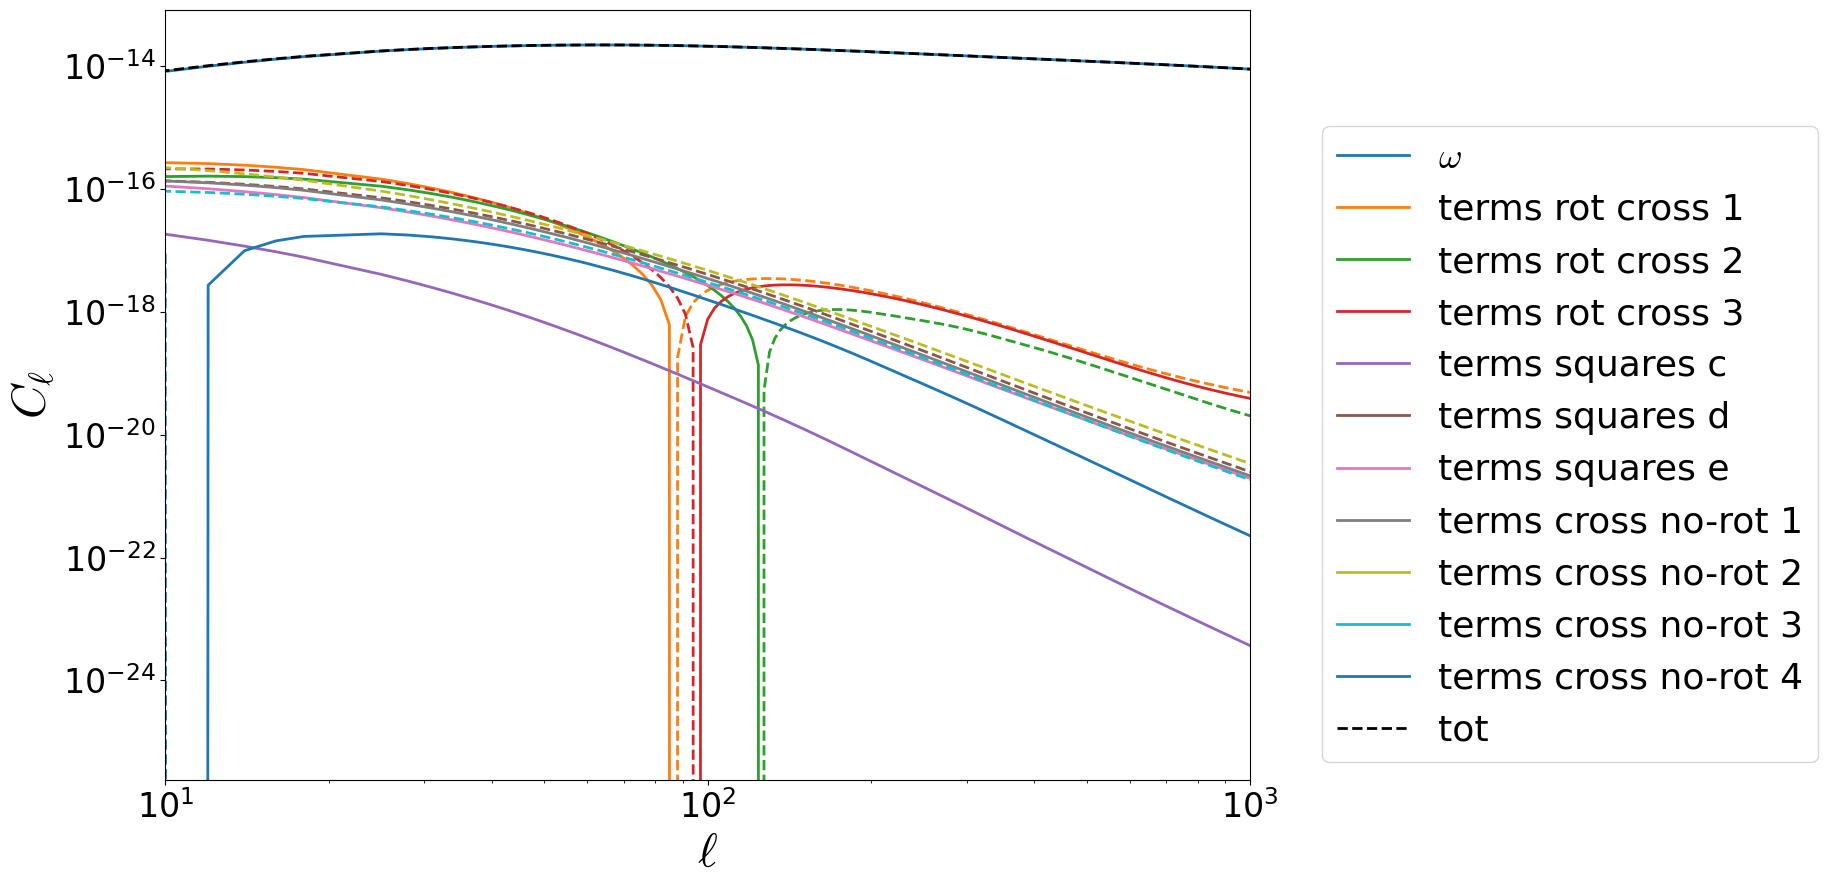

done


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pylab

plt.rcParams['mathtext.fontset'] = 'cm'

partial_sum = cl_shear_rot + cl_shear_rot_cross_1 + cl_shear_rot_cross_2 +cl_shear_rot_cross_3 + cl_shear_squares_c + cl_shear_squares_d + cl_shear_squares_e

fig = plt.figure(figsize=(14,10))
ax1 = plt.subplot()

ax1.plot(l, cl_shear_rot, ls = '-', lw = '2', color='C0', label = r'$\omega$')

ax1.plot(l, cl_shear_rot_cross_1,  ls = '-', lw = '2', color='C1', label = r'terms rot cross 1')
ax1.plot(l, -cl_shear_rot_cross_1,  ls = '--', lw = '2', color='C1')

ax1.plot(l, cl_shear_rot_cross_2,  ls = '-', lw = '2', color='C2', label = r'terms rot cross 2')
ax1.plot(l, -cl_shear_rot_cross_2,  ls = '--', lw = '2', color='C2')

ax1.plot(l, cl_shear_rot_cross_3,  ls = '-', lw = '2', color='C3', label = r'terms rot cross 3')
ax1.plot(l, -cl_shear_rot_cross_3,  ls = '--', lw = '2', color='C3')


ax1.plot(l, cl_shear_squares_c,  ls = '-', lw = '2', color='C4', label = r'terms squares c')
ax1.plot(l, -cl_shear_squares_c,  ls = '--', lw = '2', color='C4')

ax1.plot(l, cl_shear_squares_d,  ls = '-', lw = '2', color='C5', label = r'terms squares d')
ax1.plot(l, -cl_shear_squares_d,  ls = '--', lw = '2', color='C5')

ax1.plot(l, cl_shear_squares_e,  ls = '-', lw = '2', color='C6', label = r'terms squares e')
ax1.plot(l, -cl_shear_squares_e,  ls = '--', lw = '2', color='C6')

ax1.plot(l, cl_shear_cross_norot_1,  ls = '-', lw = '2', color='C7', label = r'terms cross no-rot 1')
ax1.plot(l, -cl_shear_cross_norot_1,  ls = '--', lw = '2', color='C7')

ax1.plot(l, cl_shear_cross_norot_2,  ls = '-', lw = '2', color='C8', label = r'terms cross no-rot 2')
ax1.plot(l, -cl_shear_cross_norot_2,  ls = '--', lw = '2', color='C8')

ax1.plot(l, cl_shear_cross_norot_3,  ls = '-', lw = '2', color='C9', label = r'terms cross no-rot 3')
ax1.plot(l, -cl_shear_cross_norot_3,  ls = '--', lw = '2', color='C9')

ax1.plot(l, cl_shear_cross_norot_4,  ls = '-', lw = '2', color='C10', label = r'terms cross no-rot 4')
ax1.plot(l, -cl_shear_cross_norot_4,  ls = '--', lw = '2', color='C10')

ax1.plot(l, partial_sum,  ls = '--', lw = '2', color='k', label = r'tot')

plt.legend(loc = "lower left", fontsize = 26, frameon=True, ncol = 1, bbox_to_anchor=(1.05, 0.0))

plt.ylabel('$C_{\ell}$', fontsize = 34)

plt.xscale('log')
plt.yscale('log')
plt.yticks(fontsize=24)

plt.yticks(fontsize=24)
plt.xticks(fontsize=24)

plt.xlabel('$\ell$', fontsize = 34) 
pylab.xlim([10, 1000])

plt.show()
plt.close(fig)
print('done')

# Integrals type 2

In [110]:
def cl_rad_integ_limber(string_int, results, PK, ls, nz, chi_source, setting, Hconf_source, z_snap=0.25, chi_source2=None):
    chi_source = np.float64(chi_source)
    if chi_source2 is None:
        chi_source2 = chi_source
    else:
        chi_source2 = np.float64(chi_source2)
        if chi_source2 < chi_source:
            chi_source, chi_source2 = chi_source2, chi_source
    chis = np.linspace(0, chi_source, nz, dtype=np.float64)
    zs = results.redshift_at_comoving_radial_distance(chis)
    dchis = (chis[2:] - chis[:-2]) / 2
    chis = chis[1:-1]
    zs = zs[1:-1]
    if (string_int == 'int_squares_a1'):
        win = 1 / chis ** 4
    elif (string_int == 'int_squares_a2'):
        win = 1 / chis ** 2    
    elif (string_int == 'int_squares_b'):
        win = 1 / chis ** 3 
    elif (string_int == 'int_cross_norot_5'): #mod
        win = (2 + chi_source/chis) * (1/(chi_source*Hconf_source) - 2 + 2 * chis / chi_source) / chis ** 3
    elif (string_int == 'int_cross_norot_6'): #mod
        win = (1/(chi_source*Hconf_source) - 2  + 2 * chis / chi_source)/ chis ** 4
    elif (string_int == 'int_eps_main'):
        win = (1 / chis - 1 / chi_source) * (1 / chis - 1 / chi_source) / chis ** 2
    elif (string_int == 'int_eps_corr1a'):
        win = (1 / chis - 1 / chi_source) / chis ** 3 # mod
    elif (string_int == 'int_eps_corr1b'):
        win = (1 / chis - 1 / chi_source) / chis ** 2 # mod
    else:
        raise TypeError("Input not identified.")
    cl = np.zeros(ls.shape)
    w = np.ones(chis.shape)
    for i, l in enumerate(ls):
        k = (l + 0.5) / chis
        w[:] = 1
        w[k < 1e-4] = 0
        w[k >= PK.kmax] = 0
        if (setting == 'True'):
            # compute the true contributions
            cl[i] = np.dot(dchis, w * PK.P(zs, k, grid=False) * win / k ** 4)
        elif (setting == 'comparison_sim'):
            # estimate the power spectrum at fixed redshift (z_snap) following the approximation used in the simulation
            cl[i] = np.dot(dchis, w * PK.P(z_snap, k, grid=False) * win / k ** 4)
    return cl

def get_integ_test_type2(string_type, params, setting, z_snap=0.25, kmax=100, lmax=20000, non_linear=True, z_source=None,
                             k_per_logint=None, acc=1, lsamp=None):
    results = camb.get_background(params)
    if z_source:
        chi_source = results.comoving_radial_distance(z_source)
    else:
        chi_source = results.tau0 - results.tau_maxvis
        z_source = results.redshift_at_comoving_radial_distance(chi_source)

    PK = camb.get_matter_power_interpolator(params, nonlinear=non_linear,
                                            hubble_units=False, k_hunit=False, kmax=kmax, k_per_logint=k_per_logint,
                                            var1=model.Transfer_Weyl, var2=model.Transfer_Weyl, zmax=z_source)
    return get_field_type2_power_from_PK_test(string_type, params, PK, chi_source, setting, z_snap, lmax, acc, lsamp)


def get_field_type2_power_from_PK_test(string_type, params, PK, chi_source, setting, z_snap=0.25, lmax=20000, acc=1, lsamp=None):
    results = camb.get_background(params)
    Hconf_source = results.h_of_z(z_source)/(1.0+z_source)
    nz = int(100 * acc)
    if lmax < 3000:
        raise ValueError('field rotation assumed lmax > 3000')
    ls = np.hstack((np.arange(2, 1000, 1), np.arange(1001, 2600, int(10. / acc)),
                    np.arange(2650, lmax, int(50. / acc)), np.arange(lmax, lmax + 1))).astype(np.float64)

    if (string_type == 'int_squares_a'):
        cl_int_1 =  cl_rad_integ_limber('int_squares_a1', results, PK, ls, nz, chi_source, setting, Hconf_source, z_snap, chi_source2=None)
        cl_int_2 =  cl_rad_integ_limber('int_squares_a2', results, PK, ls, nz, chi_source, setting, Hconf_source, z_snap,chi_source2=None)
    elif (string_type == 'int_eps_corr1'):
        cl_int_1 =  cl_rad_integ_limber('int_eps_corr1a', results, PK, ls, nz, chi_source, setting, Hconf_source, z_snap, chi_source2=None)
        cl_int_2 =  cl_rad_integ_limber('int_eps_corr1b', results, PK, ls, nz, chi_source, setting, Hconf_source, z_snap, chi_source2=None)
    elif (string_type == 'int_squares_b'):
        cl_int_1 =  cl_rad_integ_limber('int_squares_b', results, PK, ls, nz, chi_source, setting, Hconf_source, z_snap, chi_source2=None)
        cl_int_2 =  cl_int_1
    elif ((string_type == 'int_cross_norot_5') or (string_type == 'int_cross_norot_6')):
        cl_int_1 =  cl_rad_integ_limber(string_type, results, PK, ls, nz, chi_source, setting, Hconf_source, z_snap, chi_source2=None)
        cl_int_2 = np.zeros(ls.shape)
        for i, l in enumerate(ls):
            k = (l + 0.5) / chi_source
            w = 1
            if ((k < 1e-4) or (k >= PK.kmax)):
                w = 0
            if (setting == 'True'):
                # compute the true contributions
                cl_int_2[i] = w * PK.P(z_source, k, grid=False) / k ** 4
            elif (setting == 'comparison_sim'):
                # estimate the power spectrum at fixed redshift (z_snap) following the approximation used in the simulation
                cl_int_2[i] = w * PK.P(z_snap, k, grid=False) / k ** 4
    elif (string_type == 'int_eps_main'):
        cl_int_1 =  cl_rad_integ_limber('int_eps_main', results, PK, ls, nz, chi_source, setting, Hconf_source,  z_snap, chi_source2=None)
        cl_int_2 =  cl_int_1
    else:
        raise TypeError('Input not identified.') 
        
    M = np.outer(cl_int_1, cl_int_2)
    Mf = RectBivariateSpline(ls, ls, M)

    # L sampling for output
    if lsamp is None:
        lsamp = np.hstack((np.arange(2, 20, 2), np.arange(25, 200, 10 // acc), np.arange(220, 1200, 30 // acc),
                           np.arange(1300, min(lmax // 2, 2600), 150 // acc),
                           np.arange(3000, lmax // 2 + 1, 1000 // acc)))

    # Get field rotation (curl) spectrum.
    diagm = np.diag(M)
    diagmsp = InterpolatedUnivariateSpline(ls, diagm)
    def high_curl_integrand(_ll, _lp):
        _lp = _lp.astype(int)
        r2 = (np.float64(_ll) / _lp) ** 2
        return _lp * r2 * diagmsp(_lp) / np.pi

    clcurl = np.zeros(lsamp.shape)
    lsall = np.arange(2, lmax + 1, dtype=np.float64)

    for i, ll in enumerate(lsamp):

        ell = np.float64(ll)
        lmin = lsall[0]
        lpmax = lmax
        #lpmax = min(lmax, int(max(1000, ell * 2)))
        if ll < 1500:
            lcalc = lsall[0:lpmax - 2]
        else:
            # sampling in L', with denser around L~L'
            lcalc = np.hstack((lsall[0:20:4],
                               lsall[29:ll - 200:35],
                               lsall[ll - 190:ll + 210:6],
                               lsall[ll + 220:lpmax + 60:60]))

        tmps = np.zeros(lcalc.shape)
        for ix, lp in enumerate(lcalc):
            llp = int(lp)
            lp = np.float64(lp)
            if abs(ll - llp) > 200 and lp > 200:
                nphi = 2 * int(min(lp / 10 * acc, 200)) + 1
            elif ll > 2000:
                nphi = 2 * int(lp / 10 * acc) + 1
            else:
                nphi = 2 * int(lp) + 1
            dphi = 2 * np.pi / nphi
            phi = np.linspace(dphi, (nphi - 1) / 2 * dphi, (nphi - 1) // 2)  # even and don't need zero
            w = 2 * np.ones(phi.size)
            cosphi = np.cos(phi)
            sinphi = np.sin(phi)
            lrat = lp / ell
            lfact = np.sqrt(1 + lrat ** 2 - 2 * cosphi * lrat)
            lnorm = ell * lfact # l - L
            lfact[lfact <= 0] = 1
            w[lnorm < lmin] = 0
            w[lnorm > lmax] = 0

            lnorm = np.maximum(lmin, np.minimum(lmax, lnorm))

            if (string_type == 'int_squares_a'):
                f_phiL = lp**4*sinphi**2*cosphi**2 #mod
            elif (string_type == 'int_squares_b'):
                f_phiL = lp**3*sinphi**2*cosphi*(lp*cosphi-ll) #mod
            elif (string_type == 'int_cross_norot_5'): #mod
                f_phiL = lp**4*sinphi**2*cosphi**2
            elif (string_type == 'int_cross_norot_6'): #mod
                f_phiL = lp**4*sinphi**2*cosphi**2
            elif (string_type == 'int_eps_main'): #mod
                f_phiL = lp**3*cosphi*sinphi**2*(ll**2 + lp**2 -2.0*ll*lp*cosphi)*(lp*cosphi*(ll**2 + lp**2 -2.0*ll*lp*cosphi) + lp**2*(lp*cosphi-ll))
            elif (string_type == 'int_eps_corr1'): #mod
                f_phiL = lp**3*cosphi*sinphi**2*(2.0*lp*cosphi*(ll**2 + lp**2 -2.0*ll*lp*cosphi) + (lp*cosphi-ll)*(lp**2+(ll**2 + lp**2 -2.0*ll*lp*cosphi)))
            else:
                raise TypeError('Input not identified.') 
        
            tmps[ix] += lp*np.dot(w, f_phiL * Mf(lnorm, lp, grid=False) * dphi) #invert lp and lnorm to match the order in M matrix

        sp = InterpolatedUnivariateSpline(lcalc, tmps)

        if (string_type == 'int_squares_a'):
            K = 64.0/(chi_source**2) #mod
        elif (string_type == 'int_squares_b'):
            K = 64.0/(chi_source**2) #mod
        elif (string_type == 'int_cross_norot_5'):
            K = -16.0/(chi_source**4) #mod
        elif (string_type == 'int_cross_norot_6'):
            K = 32.0/(chi_source**3) #mod
        elif (string_type == 'int_eps_main'):
            K = 4.0
        elif (string_type == 'int_eps_corr1'):
            K = -16.0/chi_source #mod
        else:
            raise TypeError('Input not identified.') 
        clcurl[i] = sp.integral(2, lpmax - 1) * K / (2 * np.pi) ** 2
    return lsamp, clcurl

In [111]:
print('Compute integrals...')
print('z_source: ', z_source)  
print('setting: ', setting)  
int_type = 'int_squares_a'
l, cl_shear_squares_a = get_integ_test_type2(int_type, pars, setting, z_snap = 0.25, kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)

print('int_squares_a done.')

int_type = 'int_squares_b'
l, cl_shear_squares_b = get_integ_test_type2(int_type, pars, setting, z_snap = 0.25, kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)

print('int_squares_b done.')

int_type = 'int_cross_norot_5'
l, cl_shear_cross_norot_5 = get_integ_test_type2(int_type, pars, setting, z_snap = 0.25, kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)

print('int_cross_norot_5 done.')

int_type = 'int_cross_norot_6'
l, cl_shear_cross_norot_6 = get_integ_test_type2(int_type, pars, setting, z_snap = 0.25, kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)

print('int_cross_norot_6 done.')

print('Done.')

Compute integrals...
z_source:  1.0
setting:  comparison_sim
int_squares_a done.
int_squares_b done.
int_cross_norot_5 done.
int_cross_norot_6 done.
Done.


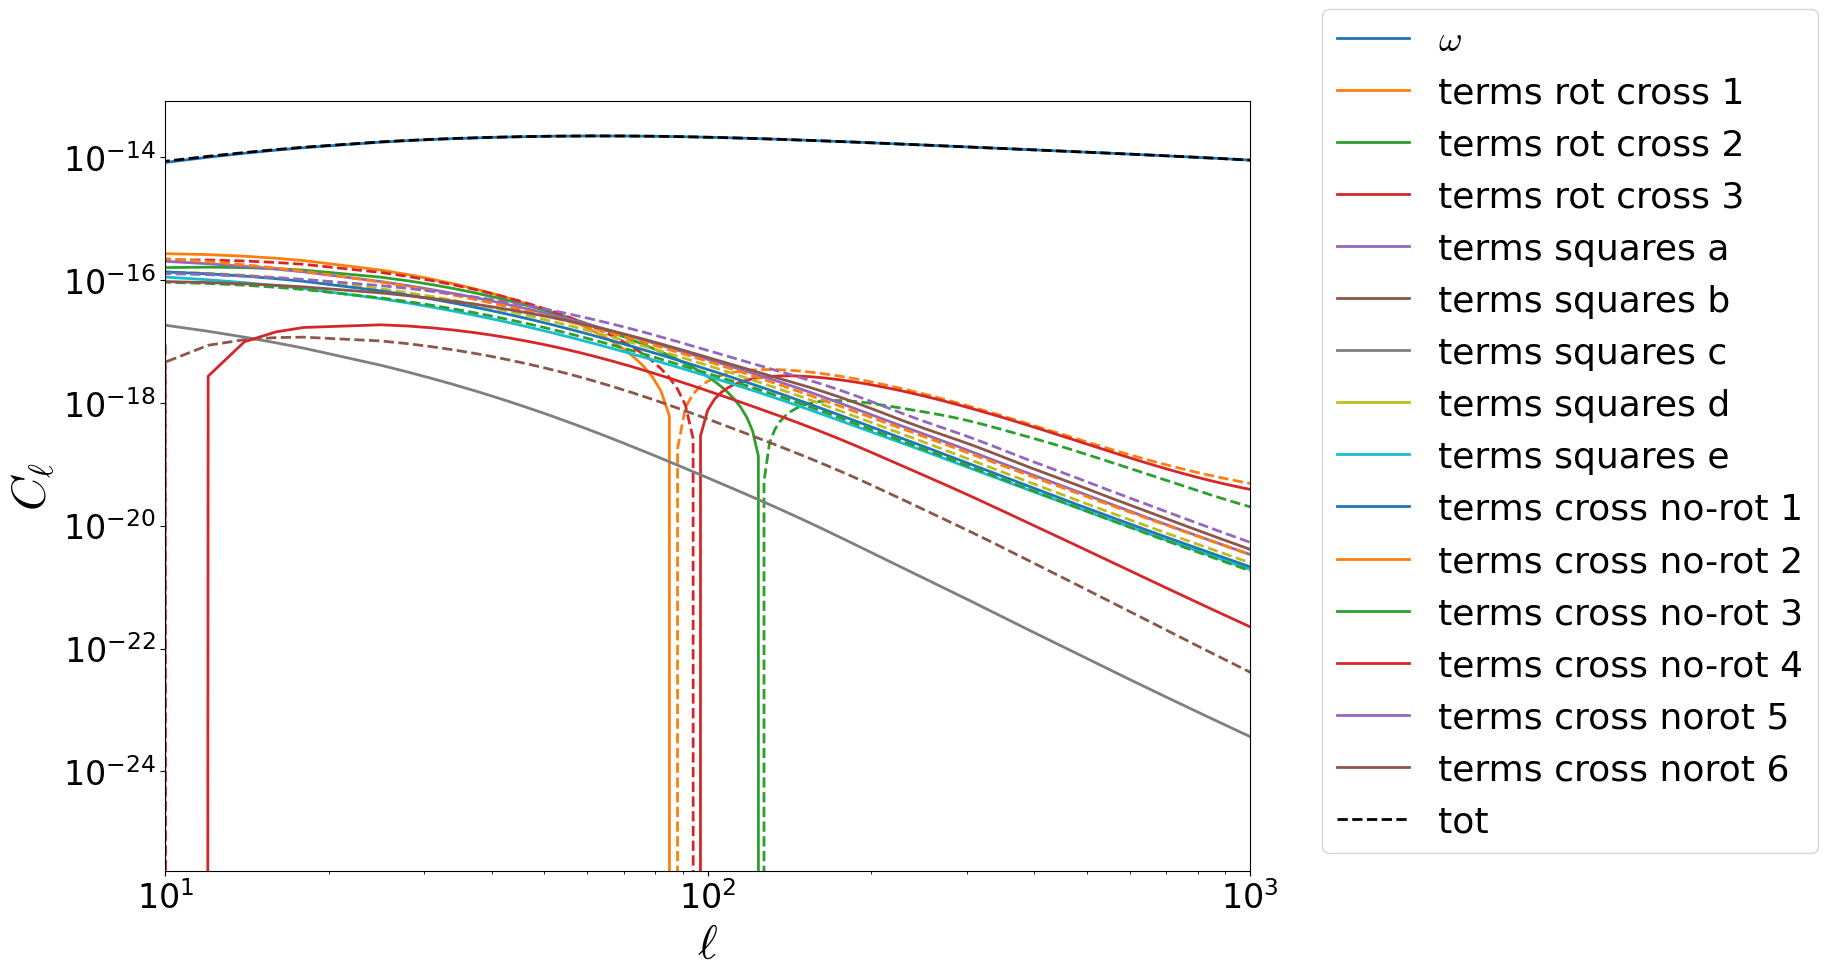

done


In [ ]:
partial_sum = cl_shear_rot + cl_shear_rot_cross_1 + cl_shear_rot_cross_2 +cl_shear_rot_cross_3 + cl_shear_squares_c + cl_shear_squares_d + cl_shear_squares_e + cl_shear_squares_a + cl_shear_squares_b + cl_shear_cross_norot_5 + cl_shear_cross_norot_6

fig = plt.figure(figsize=(14,10))
ax1 = plt.subplot()

ax1.plot(l, cl_shear_rot, ls = '-', lw = '2', color='C0', label = r'$\omega$')

ax1.plot(l, cl_shear_rot_cross_1,  ls = '-', lw = '2', color='C1', label = r'terms rot cross 1')
ax1.plot(l, -cl_shear_rot_cross_1,  ls = '--', lw = '2', color='C1')

ax1.plot(l, cl_shear_rot_cross_2,  ls = '-', lw = '2', color='C2', label = r'terms rot cross 2')
ax1.plot(l, -cl_shear_rot_cross_2,  ls = '--', lw = '2', color='C2')

ax1.plot(l, cl_shear_rot_cross_3,  ls = '-', lw = '2', color='C3', label = r'terms rot cross 3')
ax1.plot(l, -cl_shear_rot_cross_3,  ls = '--', lw = '2', color='C3')

ax1.plot(l, cl_shear_squares_a,  ls = '-', lw = '2', color='C4', label = r'terms squares a')
ax1.plot(l, -cl_shear_squares_a,  ls = '--', lw = '2', color='C4')

ax1.plot(l, cl_shear_squares_b,  ls = '-', lw = '2', color='C5', label = r'terms squares b')
ax1.plot(l, -cl_shear_squares_b,  ls = '--', lw = '2', color='C5')

ax1.plot(l, cl_shear_squares_c,  ls = '-', lw = '2', color='C7', label = r'terms squares c')
ax1.plot(l, -cl_shear_squares_c,  ls = '--', lw = '2', color='C7')

ax1.plot(l, cl_shear_squares_d,  ls = '-', lw = '2', color='C8', label = r'terms squares d')
ax1.plot(l, -cl_shear_squares_d,  ls = '--', lw = '2', color='C8')

ax1.plot(l, cl_shear_squares_e,  ls = '-', lw = '2', color='C9', label = r'terms squares e')
ax1.plot(l, -cl_shear_squares_e,  ls = '--', lw = '2', color='C9')

ax1.plot(l, cl_shear_cross_norot_1,  ls = '-', lw = '2', color='C10', label = r'terms cross no-rot 1')
ax1.plot(l, -cl_shear_cross_norot_1,  ls = '--', lw = '2', color='C10')

ax1.plot(l, cl_shear_cross_norot_2,  ls = '-', lw = '2', color='C11', label = r'terms cross no-rot 2')
ax1.plot(l, -cl_shear_cross_norot_2,  ls = '--', lw = '2', color='C11')

ax1.plot(l, cl_shear_cross_norot_3,  ls = '-', lw = '2', color='C12', label = r'terms cross no-rot 3')
ax1.plot(l, -cl_shear_cross_norot_3,  ls = '--', lw = '2', color='C12')

ax1.plot(l, cl_shear_cross_norot_4,  ls = '-', lw = '2', color='C13', label = r'terms cross no-rot 4')
ax1.plot(l, -cl_shear_cross_norot_4,  ls = '--', lw = '2', color='C13')

ax1.plot(l, cl_shear_cross_norot_5,  ls = '-', lw = '2', color='C14', label = r'terms cross norot 5')
ax1.plot(l, -cl_shear_cross_norot_5,  ls = '--', lw = '2', color='C14')

ax1.plot(l, cl_shear_cross_norot_6,  ls = '-', lw = '2', color='C15', label = r'terms cross norot 6')
ax1.plot(l, -cl_shear_cross_norot_6,  ls = '--', lw = '2', color='C15')

ax1.plot(l, partial_sum,  ls = '--', lw = '2', color='k', label = r'tot')

#add legend external to the plot
plt.legend(loc = "lower left", fontsize = 26, frameon=True, ncol = 1, bbox_to_anchor=(1.05, 0.0))

plt.ylabel('$C_{\ell}$', fontsize = 34)

plt.xscale('log')
plt.yscale('log')
plt.yticks(fontsize=24)

plt.yticks(fontsize=24)
plt.xticks(fontsize=24)

plt.xlabel('$\ell$', fontsize = 34) 
pylab.xlim([10, 1000])

plt.show()
plt.close(fig)
print('done')

# Integral square 1

In [113]:
#Compute integral squares 1 of shear contributions
from scipy.integrate import simpson

def int_square1_pk(results, PK, nz, ls, chi_source, setting, z_snap=0.25):
    """
    k_parallel integral
    """
    chi_source = np.float64(chi_source)
    zs = results.redshift_at_comoving_radial_distance(chi_source)

    # Precompute k_parallel grid ONCE
    k_par = np.logspace(-6, np.log10(PK.kmax), 1500)
    k_par2 = k_par**2

    int_l = np.zeros(ls.size)

    for il, l in enumerate(ls):
        k_perp2 = (l / chi_source)**2
        k = np.sqrt(k_perp2 + k_par2)

        if setting == 'True':
            Pk = PK.P(zs, k, grid=False)
        else:
            Pk = PK.P(z_snap, k, grid=False)

        integrand = Pk / k**4
        int_l[il] = simpson(integrand, x=k_par)

    return int_l / (np.pi) # Integrating between 0 and inf, so no 2 factor

def get_integ_square1_test(params, setting, z_snap=0.25, kmax=100, lmax=20000, non_linear=True, z_source=None,
                             k_per_logint=None, acc=1, lsamp=None):

    results = camb.get_background(params)
    if z_source:
        chi_source = results.comoving_radial_distance(z_source)
    else:
        chi_source = results.tau0 - results.tau_maxvis
        z_source = results.redshift_at_comoving_radial_distance(chi_source)

    PK = camb.get_matter_power_interpolator(params, nonlinear=non_linear,
                                            hubble_units=False, k_hunit=False, kmax=kmax, k_per_logint=k_per_logint,
                                            var1=model.Transfer_Weyl, var2=model.Transfer_Weyl, zmax=z_source)
    return get_integ_square1_from_PK_test(params, PK, chi_source, z_source, setting, z_snap, lmax, acc, lsamp)

def get_integ_square1_from_PK_test(params, PK, chi_source, z_source, setting, z_snap=0.25, lmax=20000, acc=1, lsamp=None):
    results = camb.get_background(params)
    Hconf_source = results.h_of_z(z_source)/(1.0+z_source)
    nz = int(100 * acc)
    if lmax < 3000:
        raise ValueError('field rotation assumed lmax > 3000')
    ls = np.hstack((np.arange(2, 1000, 1), np.arange(1001, 2600, int(10. / acc)),
                    np.arange(2650, lmax, int(50. / acc)), np.arange(lmax, lmax + 1))).astype(np.float64)

    # get grid of C_L(chi_s,k) for different redshifts
    chimaxs = np.linspace(0, chi_source, nz)
    cls = np.zeros((nz, ls.size))
    for i, chimax in enumerate(chimaxs[1:]):
        cl = int_square1_pk(results, PK, nz, ls, chimax, setting, z_snap)
        cls[i + 1, :] = cl
    cls[0, :] = 0
    cl_chi = RectBivariateSpline(chimaxs, ls, cls)

    # Get M(L,L') matrix
    chis = np.linspace(0, chi_source, nz, dtype=np.float64)
    zs = results.redshift_at_comoving_radial_distance(chis)
    dchis = (chis[2:] - chis[:-2]) / 2
    chis = chis[1:-1]
    zs = zs[1:-1]
    win = (2 - 1/(chi_source * Hconf_source) - 2*chis/chi_source)**2/chis ** 4
    w = np.ones(chis.shape)
    cchi = cl_chi(chis, ls, grid=True)
    M = np.zeros((ls.size, ls.size))
    for i, ell in enumerate(ls):
        k = (ell + 0.5) / chis
        w[:] = 1
        w[k < 1e-4] = 0
        w[k >= PK.kmax] = 0
        if setting == 'True':
            # compute the true contributions
            cl = np.dot(dchis * w * PK.P(zs, k, grid=False) * win / k ** 4, cchi)
        elif setting == 'comparison_sim':
            # estimate the power spectrum at fixed redshift (z_snap) following the approximation used in the simulation
            cl = np.dot(dchis * w * PK.P(z_snap, k, grid=False) * win / k ** 4, cchi)
        M[i, :] = cl 
    Mf = RectBivariateSpline(ls, ls, np.log(M))

    # L sampling for output
    if lsamp is None:
        lsamp = np.hstack((np.arange(2, 20, 2), np.arange(25, 200, 10 // acc), np.arange(220, 1200, 30 // acc),
                           np.arange(1300, min(lmax // 2, 2600), 150 // acc),
                           np.arange(3000, lmax // 2 + 1, 1000 // acc)))

    # Get field rotation (curl) spectrum.
    diagm = np.diag(M)
    diagmsp = InterpolatedUnivariateSpline(ls, diagm)

    def high_curl_integrand(_ll, _lp):
        _lp = _lp.astype(int)
        r2 = (np.float64(_ll) / _lp) ** 2
        return _lp * r2 * diagmsp(_lp) / np.pi

    clcurl = np.zeros(lsamp.shape)
    lsall = np.arange(2, lmax + 1, dtype=np.float64)

    for i, ll in enumerate(lsamp):

        ell = np.float64(ll)
        lmin = lsall[0]
        lpmax = lmax#min(lmax, int(max(1000, ell * 2)))

        if ll < 1500:
            lcalc = lsall[0:lpmax - 2]
        else:
            # sampling in L', with denser around L~L'
            lcalc = np.hstack((lsall[0:20:4],
                               lsall[29:ll - 200:35],
                               lsall[ll - 190:ll + 210:6],
                               lsall[ll + 220:lpmax + 60:60]))
            
        tmps = np.zeros(lcalc.shape)
        for ix, lp in enumerate(lcalc):
            llp = int(lp)
            lp = np.float64(lp)
            if abs(ll - llp) > 200 and lp > 200:
                nphi = 2 * int(min(lp / 10 * acc, 200)) + 1
            elif ll > 2000:
                nphi = 2 * int(lp / 10 * acc) + 1
            else:
                nphi = 2 * int(lp) + 1
            dphi = 2 * np.pi / nphi
            phi = np.linspace(dphi, (nphi - 1) / 2 * dphi, (nphi - 1) // 2)  # even and don't need zero
            w = 2 * np.ones(phi.size)
            cosphi = np.cos(phi)
            sinphi = np.sin(phi)
            lrat = lp / ell
            lfact = np.sqrt(1 + lrat ** 2 - 2 * cosphi * lrat)
            lnorm = ell * lfact
            lfact[lfact <= 0] = 1
            w[lnorm < lmin] = 0
            w[lnorm > lmax] = 0

            lnorm = np.maximum(lmin, np.minimum(lmax, lnorm))
            tmps[ix] += lp*np.dot(w,  (lp**4 * cosphi**2 * sinphi**2  *
                                    np.exp(Mf(lnorm, lp, grid=False))) * dphi)

        sp = InterpolatedUnivariateSpline(lcalc, tmps)
        K = 4.0/chi_source**2
        clcurl[i] = sp.integral(2, lpmax - 1) * K / (2 * np.pi) ** 2

    return lsamp, clcurl

print('Compute integrals...')
print('z_source: ', z_source)  
print('setting: ', setting)  
l, cl_shear_squares_1 = get_integ_square1_test(pars, setting='comparison_sim', z_snap=0.25, kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)
print('int_squares_1 done.')

Compute integrals...
z_source:  1.0
setting:  comparison_sim
int_squares_1 done.


# Integral square 2

In [114]:
def get_integ_test_square2(params, setting,z_snap = 0.25, kmax=100, lmax=20000, non_linear=True, z_source=None,
                             k_per_logint=None, acc=1, lsamp=None):

    results = camb.get_background(params)
    if z_source:
        chi_source = results.comoving_radial_distance(z_source)
    else:
        chi_source = results.tau0 - results.tau_maxvis
        z_source = results.redshift_at_comoving_radial_distance(chi_source)

    PK = camb.get_matter_power_interpolator(params, nonlinear=non_linear,
                                            hubble_units=False, k_hunit=False, kmax=kmax, k_per_logint=k_per_logint,
                                            var1=model.Transfer_Weyl, var2=model.Transfer_Weyl, zmax=z_source)
    return get_field_type3_power_from_PK_test(params, PK, chi_source, z_source, setting, z_snap, lmax, acc, lsamp)


def get_field_square2_power_from_PK_test(params, PK, chi_source, z_source, setting, z_snap = 0.25, lmax=20000, acc=1, lsamp=None):
    results = camb.get_background(params)
    Hconf_source = results.h_of_z(z_source)/(1.0+z_source)
    nz = int(100 * acc)
    if lmax < 3000:
        raise ValueError('field rotation assumed lmax > 3000')
    ls = np.hstack((np.arange(2, 1000, 1), np.arange(1001, 2600, int(10. / acc)),
                    np.arange(2650, lmax, int(50. / acc)), np.arange(lmax, lmax + 1))).astype(np.float64)

    cl = np.zeros(ls.shape)
    for i, l in enumerate(ls):
        k = (l + 0.5) / chi_source
        w = 1
        if ((k < 1e-4) or (k >= PK.kmax)):
            w = 0
        if (setting == 'True'): 
            # compute the true contributions
            cl[i] = w * PK.P(z_source, k, grid=False) / k ** 4
        elif (setting == 'comparison_sim'):
            # estimate the power spectrum at fixed redshift (z_snap) following the approximation used in the simulation
            cl[i] = w * PK.P(z_snap, k, grid=False) / k ** 4
     
    M = np.outer(cl, cl)
    Mf = RectBivariateSpline(ls, ls, M)

    # L sampling for output
    if lsamp is None:
        lsamp = np.hstack((np.arange(2, 20, 2), np.arange(25, 200, 10 // acc), np.arange(220, 1200, 30 // acc),
                           np.arange(1300, min(lmax // 2, 2600), 150 // acc),
                           np.arange(3000, lmax // 2 + 1, 1000 // acc)))

    # Get field rotation (curl) spectrum.
    diagm = np.diag(M)
    diagmsp = InterpolatedUnivariateSpline(ls, diagm)

    clcurl = np.zeros(lsamp.shape)
    lsall = np.arange(2, lmax + 1, dtype=np.float64)

    for i, ll in enumerate(lsamp):

        ell = np.float64(ll)
        lmin = lsall[0]
        lpmax = lmax
        #lpmax = min(lmax, int(max(1000, ell * 2)))
        if ll < 1500:
            lcalc = lsall[0:lpmax - 2]
        else:
            # sampling in L', with denser around L~L'
            lcalc = np.hstack((lsall[0:20:4],
                               lsall[29:ll - 200:35],
                               lsall[ll - 190:ll + 210:6],
                               lsall[ll + 220:lpmax + 60:60]))

        tmps = np.zeros(lcalc.shape)
        for ix, lp in enumerate(lcalc):
            llp = int(lp)
            lp = np.float64(lp)
            if abs(ll - llp) > 200 and lp > 200:
                nphi = 2 * int(min(lp / 10 * acc, 200)) + 1
            elif ll > 2000:
                nphi = 2 * int(lp / 10 * acc) + 1
            else:
                nphi = 2 * int(lp) + 1
            dphi = 2 * np.pi / nphi
            phi = np.linspace(dphi, (nphi - 1) / 2 * dphi, (nphi - 1) // 2)  # even and don't need zero
            w = 2 * np.ones(phi.size)
            cosphi = np.cos(phi)
            sinphi = np.sin(phi)
            lrat = lp / ell
            lfact = np.sqrt(1 + lrat ** 2 - 2 * cosphi * lrat)
            lnorm = ell * lfact # l - L
            lfact[lfact <= 0] = 1
            w[lnorm < lmin] = 0
            w[lnorm > lmax] = 0

            lnorm = np.maximum(lmin, np.minimum(lmax, lnorm))

            f_phiL = lp**3*cosphi*sinphi**2*(lp*cosphi-ll) #mod        
            tmps[ix] += lp*np.dot(w, f_phiL * Mf(lp, lnorm, grid=False) * dphi)

        sp = InterpolatedUnivariateSpline(lcalc, tmps)

        K = 4.0/(chi_source**6) * (1.0/(chi_source*Hconf_source))**2 
        clcurl[i] = sp.integral(2, lpmax - 1) * K / (2 * np.pi) ** 2
    return lsamp, clcurl

print('Compute integral square 2...')
print('z_source: ', z_source)  
print('setting: ', setting)  
l, cl_shear_squares_2 = get_integ_test_square2(pars, setting, z_snap = 0.25, kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)

print('int_squares_2 done.')

print('Done.')

Compute integral square 2...
z_source:  1.0
setting:  comparison_sim
int_squares_2 done.
Done.


In [ ]:
# Save data to a file
partial_sum_rot_cross = cl_shear_rot_cross_1 + cl_shear_rot_cross_2 + cl_shear_rot_cross_3
partial_sum_cross_norot = cl_shear_cross_norot_1 + cl_shear_cross_norot_2 + cl_shear_cross_norot_3 + cl_shear_cross_norot_4 + cl_shear_cross_norot_5 + cl_shear_cross_norot_6
partial_sum_squares = cl_shear_squares_a + cl_shear_squares_b + cl_shear_squares_c + cl_shear_squares_d + cl_shear_squares_e + cl_shear_squares_1 + cl_shear_squares_2

total_square_terms = partial_sum_rot_cross + partial_sum_squares + partial_sum_cross_norot
path = 'theory/integrals_shearB/'
data = {
    'l': l,
    'int_rot': cl_shear_rot,
    'int_rot_cross': partial_sum_rot_cross,
    'int_squares_norot': partial_sum_squares,
    'int_cross_norot': partial_sum_cross_norot,
    'sum_correction': total_square_terms
}

# Save the data to a text file
np.savez(path +'integrals_shearBmodes_sums_z1_sim.npz', **data)

In [ ]:
# Save data to a file
partial_sum_rot_cross = cl_shear_rot_cross_1 + cl_shear_rot_cross_2 + cl_shear_rot_cross_3
partial_sum_cross_norot = cl_shear_cross_norot_1 + cl_shear_cross_norot_2 + cl_shear_cross_norot_3 + cl_shear_cross_norot_4 + cl_shear_cross_norot_5 + cl_shear_cross_norot_6
partial_sum_squares = cl_shear_squares_a + cl_shear_squares_b + cl_shear_squares_c + cl_shear_squares_d + cl_shear_squares_e + cl_shear_squares_2
total_square_terms = partial_sum_rot_cross + partial_sum_squares + partial_sum_cross_norot
path = 'theory/integrals_shearB/'
data = {
    'l': l,
    'int_rot': cl_shear_rot,
    'int_rot_cross_1': cl_shear_rot_cross_1,
    'int_rot_cross_2': cl_shear_rot_cross_2,
    'int_rot_cross_3': cl_shear_rot_cross_3,
    'int_squares_norot_a': cl_shear_squares_a,
    'int_squares_norot_b': cl_shear_squares_b,
    'int_squares_norot_c': cl_shear_squares_c,
    'int_squares_norot_d': cl_shear_squares_d,
    'int_squares_norot_e': cl_shear_squares_e,
    'int_squares_norot_1': cl_shear_squares_1,
    'int_squares_norot_2': cl_shear_squares_2,
    'int_cross_norot_1': cl_shear_cross_norot_1,
    'int_cross_norot_2': cl_shear_cross_norot_2,
    'int_cross_norot_3': cl_shear_cross_norot_3,
    'int_cross_norot_4': cl_shear_cross_norot_4,
    'int_cross_norot_5': cl_shear_cross_norot_5,
    'int_cross_norot_6': cl_shear_cross_norot_6,
    'sum_correction': total_square_terms
}

# Save the data to a text file
np.savez(path+ 'integrals_shearBmodes_terms_z1_sim.npz', **data)

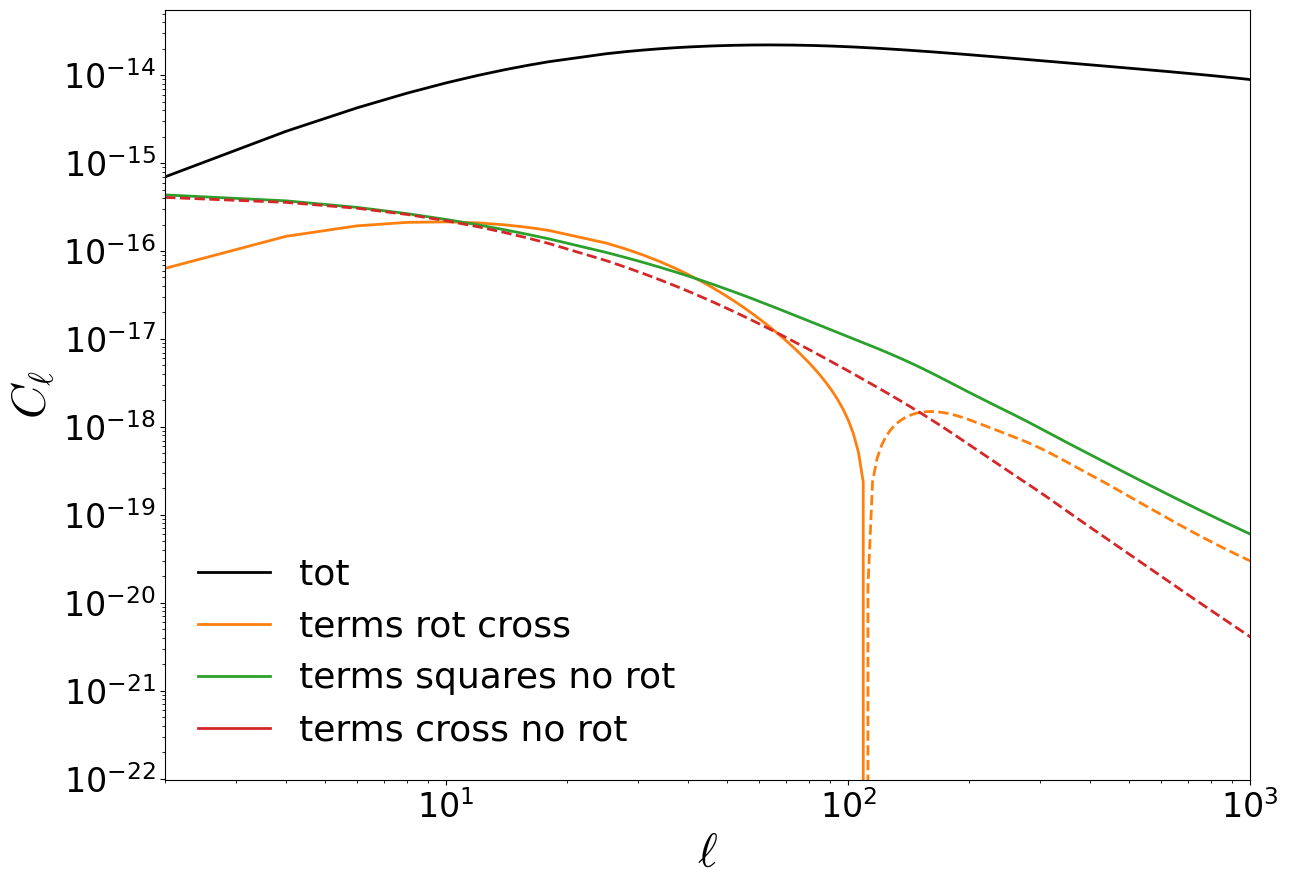

done


In [ ]:
partial_sum_rot_cross = cl_shear_rot_cross_1 + cl_shear_rot_cross_2 + cl_shear_rot_cross_3
partial_sum_cross_norot = cl_shear_cross_norot_1 + cl_shear_cross_norot_2 + cl_shear_cross_norot_3 + cl_shear_cross_norot_4 + cl_shear_cross_norot_5 + cl_shear_cross_norot_6
partial_sum_squares = cl_shear_squares_a + cl_shear_squares_b + cl_shear_squares_c + cl_shear_squares_d + cl_shear_squares_e + cl_shear_squares_1 + cl_shear_squares_2

partial_sum = partial_sum_rot_cross + partial_sum_cross_norot + partial_sum_squares

fig = plt.figure(figsize=(14,10))
ax1 = plt.subplot()

ax1.plot(l, cl_shear_rot,  ls = '-', lw = '2', color='k', label = r'tot')

ax1.plot(l, partial_sum_rot_cross,  ls = '-', lw = '2', color='C1', label = r'terms rot cross')
ax1.plot(l, -partial_sum_rot_cross,  ls = '--', lw = '2', color='C1')#, label = r'shear 3')

ax1.plot(l, partial_sum_squares,  ls = '-', lw = '2', color='C2', label = r'terms squares no rot')
ax1.plot(l, -partial_sum_squares,  ls = '--', lw = '2', color='C2')#, label = r'shear 3')

ax1.plot(l, partial_sum_cross_norot,  ls = '-', lw = '2', color='C3', label = r'terms cross no rot')
ax1.plot(l, -partial_sum_cross_norot,  ls = '--', lw = '2', color='C3')#, label = r'shear 3')


plt.legend(loc = "lower left", fontsize = 26, frameon=False, ncol = 1)

plt.ylabel('$C_{\ell}$', fontsize = 34)

plt.xscale('log')
plt.yscale('log')
plt.yticks(fontsize=24)

plt.yticks(fontsize=24)
plt.xticks(fontsize=24)#, rotation=90)

plt.xlabel('$\ell$', fontsize = 34) 
pylab.xlim([2, 1000])

plt.show()
plt.close(fig)
print('done')

# Ellipticity

In [117]:
print('Compute integrals...')
z_source = 1.0
print('z_source: ', z_source)  
print('setting: ', setting)  
int_type = 'int_eps_main'
l, cl_eps_main = get_integ_test_type2(int_type, pars, setting, z_snap = 0.25, kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)

print('int_eps_main done.')

int_type = 'int_eps_crossrot'
l, cl_eps_crossrot = get_integ_type1(int_type, pars, setting, z_snap = 0.25, kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)

print('int_eps_crossrot done.')
print('Done.')

Compute integrals...
z_source:  1.0
setting:  comparison_sim
int_eps_main done.
int_eps_crossrot done.
Done.


In [118]:
print('Compute integrals...')
print('z_source: ', z_source)  
print('setting: ', setting)  

int_type = 'int_eps_corr1'
l, cl_eps_corr1 = get_integ_test_type2(int_type, pars, setting, z_snap = 0.25, kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)

print('int_eps_corr1 done.')

int_type = 'int_eps_corr2'
l, cl_eps_corr2 = get_integ_type1(int_type, pars, setting, z_snap = 0.25, kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)

print('int_eps_corr2 done.')

int_type = 'int_eps_corr3'
l, cl_eps_corr3 = get_integ_type1(int_type, pars, setting, z_snap = 0.25, kmax=100, lmax=5000, non_linear=True, z_source=z_source,
                             k_per_logint=None, acc=3, lsamp=None)

print('int_eps_corr3 done.')

print('Done.')

Compute integrals...
z_source:  1.0
setting:  comparison_sim
int_eps_corr1 done.
int_eps_corr2 done.
int_eps_corr3 done.
Done.


In [ ]:
path = 'theory/integrals_shearB/'
data = {
    'l': l,
    'int_eps_main': cl_eps_main,
    'int_eps_crossrot': cl_eps_crossrot,
    'int_eps_corr1': cl_eps_corr1,
    'int_eps_corr2': cl_eps_corr2,
    'int_eps_corr3': cl_eps_corr3,
    'sum_correction': cl_eps_main + cl_eps_crossrot + cl_eps_corr1 + cl_eps_corr2 + cl_eps_corr3
}

# Save the data to a text file
np.savez(path +'integrals_epsBmodes_terms_z1_sim.npz', **data) 
print('File saved.')


File saved.
